In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import QuantileTransformer
import re
import pickle

### Load Dataset

In [2]:
# Load Datasets
occupations_df = pd.read_csv("Occupation Data.csv")
skills_df = pd.read_csv("Skills.csv")
knowledge_df = pd.read_csv("Knowledge.csv")
tech_skills_df = pd.read_csv("Technology Skills.csv")

### Summary Table

In [3]:
onet_dfs = [
    skills_df,
    knowledge_df,
    tech_skills_df,
    occupations_df
]

onet_names = [
    "Skills",
    "Knowledge",
    "Technology_Skills",
    "Occupations"
]

summary_list = []

for df, name in zip(onet_dfs, onet_names):
    total_rows = df.shape[0]
    total_columns = df.shape[1]
    
    # Missing values
    missing_total = df.isnull().sum().sum()
    missing_pct = round(
        (missing_total / (total_rows * total_columns)) * 100, 2
    ) if total_rows > 0 else 0
    
    # Duplicates
    duplicate_count = df.duplicated().sum()
    
    # Column names
    columns_list = ", ".join(df.columns.tolist())
    
    # SOC coverage
    soc_count = df["O*NET-SOC Code"].nunique() if "O*NET-SOC Code" in df.columns else None
    
    # Scale ID distribution
    scale_ids = (
        ", ".join(df["Scale ID"].unique().astype(str))
        if "Scale ID" in df.columns
        else None
    )
    
    summary_list.append({
        "Dataset": name,
        "Rows": total_rows,
        "Columns": total_columns,
        "Unique_SOC_Codes": soc_count,
        "Scale_IDs_Present": scale_ids,
        "Total_Missing_Values": missing_total,
        "Missing_Percentage (%)": missing_pct,
        "Duplicate_Rows": duplicate_count,
        "Column_Names": columns_list
    })
    
onet_summary_df = pd.DataFrame(summary_list)


In [4]:
compact_summary = onet_summary_df.drop(columns=["Column_Names"])

print(compact_summary)


             Dataset   Rows  Columns  Unique_SOC_Codes Scale_IDs_Present  \
0             Skills  62580       15               894            IM, LV   
1          Knowledge  59004       15               894            IM, LV   
2  Technology_Skills  32681        7               923              None   
3        Occupations   1016        3              1016              None   

   Total_Missing_Values  Missing_Percentage (%)  Duplicate_Rows  
0                 31290                    3.33               0  
1                 90608                   10.24               0  
2                     0                    0.00               0  
3                     0                    0.00               0  


In [27]:
print("--- Occupations ---")
print(occupations_df.head())
print(occupations_df.info())

--- Occupations ---
  O*NET-SOC Code                                Title  \
0     11-1011.00                     Chief Executives   
1     11-1011.03        Chief Sustainability Officers   
2     11-1021.00      General and Operations Managers   
3     11-1031.00                          Legislators   
4     11-2011.00  Advertising and Promotions Managers   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          Description  
0                                                                                                    

In [28]:
# Drop unused columns
DROP_COLS = [
    "N",
    "Standard Error",
    "Lower CI Bound",
    "Upper CI Bound",
    "Recommend Suppress",
    "Not Relevant",
    "Date",
    "Domain Source",
    "Title"
]

skills_df = skills_df.drop(columns=DROP_COLS)
knowledge_df = knowledge_df.drop(columns=DROP_COLS)

# Keep only Importance scale records
skills_df = skills_df[skills_df["Scale ID"] == "IM"].copy()
knowledge_df = knowledge_df[knowledge_df["Scale ID"] == "IM"].copy()

# Remove rows with missing values
skills_df = skills_df.dropna()
knowledge_df = knowledge_df.dropna()
tech_skills_df = tech_skills_df.dropna()

# Keep only Hot Technology or In Demand
tech_skills_filtered_df = tech_skills_df[
    (tech_skills_df["Hot Technology"] == "Y") |
    (tech_skills_df["In Demand"] == "Y")
].copy()

print("Dropped unused columns")
print("Filtered only Importance scale records")
print("Removed missing values")
print(f"Shapes -> \nSkills: {skills_df.shape}, \nKnowledge: {knowledge_df.shape}, \nTech Skills: {tech_skills_df.shape}")
print(f"\nFiltered tech skills (Hot/In-Demand), resulting shape: {tech_skills_filtered_df.shape}")
print("Data cleaning completed")



Dropped unused columns
Filtered only Importance scale records
Removed missing values
Shapes -> 
Skills: (31290, 6), 
Knowledge: (29502, 6), 
Tech Skills: (32681, 7)

Filtered tech skills (Hot/In-Demand), resulting shape: (11923, 7)
Data cleaning completed


### Feature Engineering on Technology Skill's Importance Score

In [ ]:
# ===== Skill Importance Scoring using Inverse Occupation Frequency (IOF) + Demand Signals =====

# Reset index to avoid misalignment later
tech_skills_filtered_df = tech_skills_filtered_df.reset_index(drop=True)

# Compute Inverse Occupation Frequency (IOF)
N = tech_skills_filtered_df['O*NET-SOC Code'].nunique()

# Count number of occupations per tech skill
skill_occ_count = tech_skills_filtered_df.groupby('Example')['O*NET-SOC Code'].nunique()

# Assign IOF
tech_skills_filtered_df['IOF'] = tech_skills_filtered_df['Example'].map(
    lambda x: np.log(N / (1 + skill_occ_count[x]))
)

# Base Importance Score (Hot + In Demand)
tech_skills_filtered_df['Base_Score'] = (
    tech_skills_filtered_df['Hot Technology'].eq('Y').astype(float) +
    tech_skills_filtered_df['In Demand'].eq('Y').astype(float)
)

# Apply IOF weighting
tech_skills_filtered_df['Weighted_Score'] = tech_skills_filtered_df['Base_Score'] * tech_skills_filtered_df['IOF']

# Quantile Transform to Normal Distribution
qt = QuantileTransformer(output_distribution='normal', random_state=42)
weighted_array = qt.fit_transform(tech_skills_filtered_df[['Weighted_Score']])

# Convert back to Series with correct index
tech_skills_filtered_df['Importance_Score_Normal'] = pd.Series(weighted_array.flatten(), index=tech_skills_filtered_df.index)

# Scale to 0–5 range
min_val = tech_skills_filtered_df['Importance_Score_Normal'].min()
max_val = tech_skills_filtered_df['Importance_Score_Normal'].max()

tech_skills_filtered_df['Data Value'] = (
    (tech_skills_filtered_df['Importance_Score_Normal'] - min_val) /
    (max_val - min_val)
) * 5

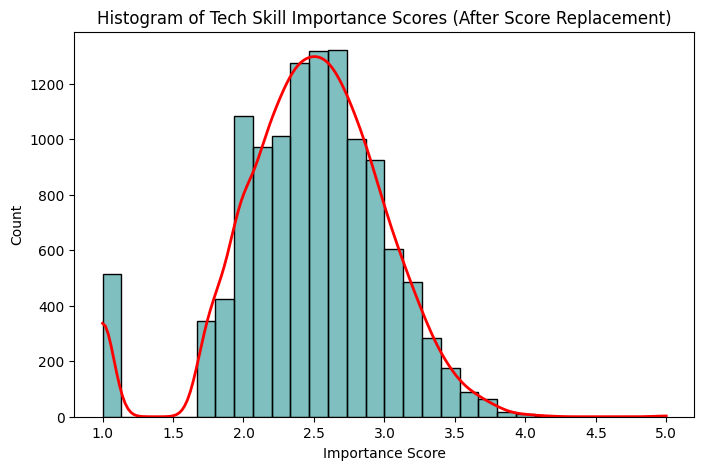

In [ ]:
# Replace Data Value of 0 with 1 to avoid zero importance scores issue
tech_skills_filtered_df['Data Value'] = tech_skills_filtered_df['Data Value'].replace(0, 1)

plt.figure(figsize=(8,5))

# Create the plot and save it to a variable 'ax'
ax = sns.histplot(
    tech_skills_filtered_df['Data Value'], 
    bins=30, 
    kde=True, 
    color='teal' 
)

# Manually grab the KDE line
if len(ax.lines) > 0:
    ax.lines[0].set_color('red')
    ax.lines[0].set_linewidth(2)

plt.title("Histogram of Tech Skill Importance Scores (After Score Replacement)")
plt.xlabel("Importance Score")
plt.ylabel("Count")
plt.show()

### Column Name Harmonization

In [32]:
# 1. Harmonize datasets before combine
def prepare_domain(df, domain_name):
    return df.rename(columns={
        "O*NET-SOC Code": "ONET_SOC_Code",
        "Element ID": "Feature_ID",
        "Element Name": "Feature_Name",
        "Data Value": "Importance_Score"
    }).assign(Feature_Type=domain_name)[
        ["ONET_SOC_Code", "Feature_Type", "Feature_ID", "Feature_Name", "Importance_Score"]
    ]

skills_final = prepare_domain(skills_df, "Skill")
knowledge_final = prepare_domain(knowledge_df, "Knowledge")

tech_skills_final = tech_skills_filtered_df.rename(columns={
    "O*NET-SOC Code": "ONET_SOC_Code",
    "Example": "Feature_Name",   # Technology name
    "Commodity Code": "Feature_ID",     
    "Data Value": "Importance_Score" 
}).assign(Feature_Type="TechnologySkills")[
        ["ONET_SOC_Code", "Feature_Type", "Feature_ID", "Feature_Name", "Importance_Score"]
    ]

# Simply rename occupations column without pre-cleaning rows
occupations_df = occupations_df.rename(columns={"O*NET-SOC Code": "ONET_SOC_Code"})

### Combine the datasets into a unified occupation dataset

In [ ]:
# 2. Combine all feature datasets
combined_dataset = pd.concat(
    [skills_final, knowledge_final, tech_skills_final],
    ignore_index=True
)

# 3. Merge with Occupation Titles (brings in the Title column)
unified_occupation_dataset = combined_dataset.merge(
    occupations_df[['ONET_SOC_Code', 'Title']],
    on='ONET_SOC_Code',
    how='left'
)

# 4. Clean rows with ANY missing values to ensure full info per row
unified_occupation_dataset = unified_occupation_dataset.dropna()

# 5. Ensure occupation exists in Skills AND Knowledge AND TechnologySkills
valid_soc_codes = (
    set(skills_final['ONET_SOC_Code']) & 
    set(knowledge_final['ONET_SOC_Code']) & 
    set(tech_skills_final['ONET_SOC_Code'])
)

# Filter the unified dataset to only include occupations that have all three feature types
unified_occupation_dataset = unified_occupation_dataset[
    unified_occupation_dataset['ONET_SOC_Code'].isin(valid_soc_codes)
]

# 6. Reorder columns
unified_occupation_dataset = unified_occupation_dataset[[
    "ONET_SOC_Code", "Title", "Feature_Type", "Feature_ID", "Feature_Name", "Importance_Score"
]]

# Save unified dataset
output_filename = 'Unified_Occupation_Dataset.csv'
unified_occupation_dataset.to_csv(output_filename, index=False)
print(f"File saved: {output_filename} | Final Shape: {unified_occupation_dataset.shape}")

File saved: Unified_Occupation_Dataset.csv | Final Shape: (70817, 6)


### Export features of the dataset

In [34]:
def preserve_tech_syntax(text):
    """
    Cleans technical text while preserving:
    - alphanumeric tokens
    - +, #, .
    Converts text to lowercase and removes noise characters.
    """
    if not isinstance(text, str):
        return ""
    return ' '.join(
        re.sub(r'[^a-z0-9\+\#\.]', ' ', str(text).lower()).split()
    )

# Export master vocabulary for consistent vectorization in future modeling
df_occ = pd.read_csv('Unified_Occupation_Dataset.csv')

df_occ['Clean_Feature'] = df_occ['Feature_Name'].apply(preserve_tech_syntax)

master_vocab = (
    df_occ['Clean_Feature']
    .dropna()
    .drop_duplicates()
    .sort_values()
    .tolist()
)

with open('master_vocab.pkl', 'wb') as f:
    pickle.dump(master_vocab, f)

print("Done Creating Master Vocab with total features of: ", len(master_vocab))


Done Creating Master Vocab with total features of:  366


## Data Understanding

In [6]:
unified_occupation_dataset = pd.read_csv('Unified_Occupation_Dataset.csv')

In [7]:
print("Dataset shape:", unified_occupation_dataset.shape)
print()
print(unified_occupation_dataset.head())
print(unified_occupation_dataset.info())

# Check for unique values in categorical columns to understand the scope
print("\nUnique Feature Types:", unified_occupation_dataset['Feature_Type'].unique())
print("Number of unique Occupations:", unified_occupation_dataset['Title'].nunique())

Dataset shape: (70817, 6)

  ONET_SOC_Code             Title Feature_Type Feature_ID  \
0    11-1011.00  Chief Executives        Skill    2.A.1.a   
1    11-1011.00  Chief Executives        Skill    2.A.1.b   
2    11-1011.00  Chief Executives        Skill    2.A.1.c   
3    11-1011.00  Chief Executives        Skill    2.A.1.d   
4    11-1011.00  Chief Executives        Skill    2.A.1.e   

            Feature_Name  Importance_Score  
0  Reading Comprehension              4.12  
1       Active Listening              4.00  
2                Writing              4.12  
3               Speaking              4.25  
4            Mathematics              3.25  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70817 entries, 0 to 70816
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ONET_SOC_Code     70817 non-null  object 
 1   Title             70817 non-null  object 
 2   Feature_Type      70817 non-null  o

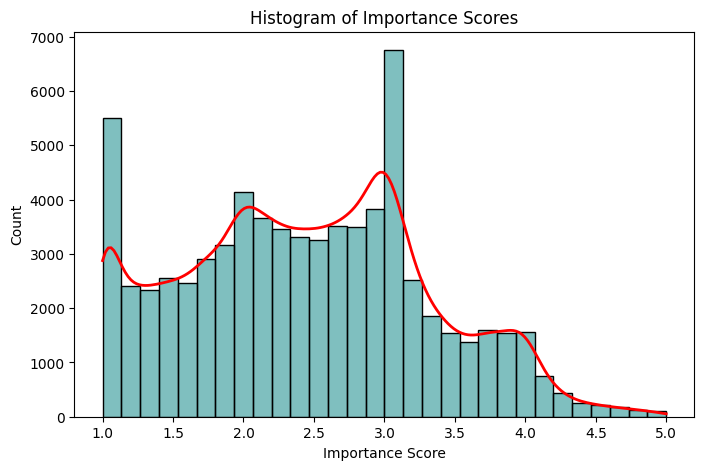

In [ ]:
plt.figure(figsize=(8,5))

# 1. Create the plot and save it to a variable 'ax'
ax = sns.histplot(
    unified_occupation_dataset['Importance_Score'], 
    bins=30, 
    kde=True, 
    color='teal' 
)

# 2. Manually grab the KDE line
if len(ax.lines) > 0:
    ax.lines[0].set_color('red')
    ax.lines[0].set_linewidth(2)

plt.title("Histogram of Importance Scores")
plt.xlabel("Importance Score")
plt.ylabel("Count")
plt.show()

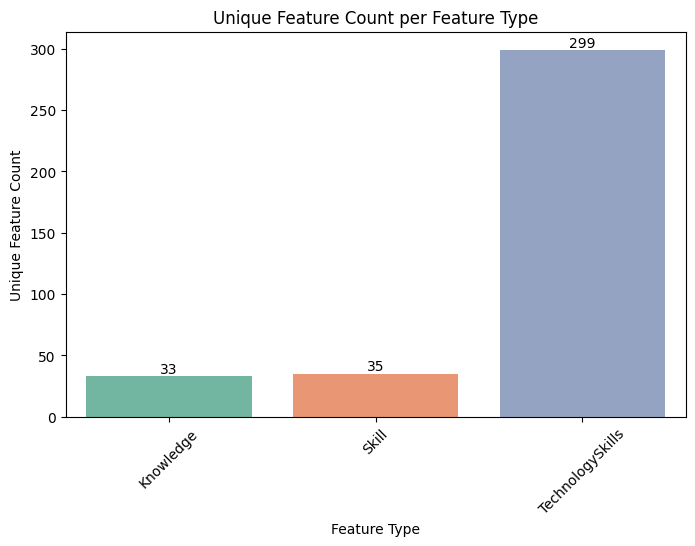

In [9]:
plt.figure(figsize=(8,5))

feature_counts = unified_occupation_dataset.groupby('Feature_Type')['Feature_Name'].nunique().reset_index()
feature_counts.columns = ['Feature_Type', 'Unique_Feature_Count']

chart = sns.barplot(
    data=feature_counts,
    x='Feature_Type',
    y='Unique_Feature_Count',
    palette='Set2',
    hue='Feature_Type'
)

plt.title("Unique Feature Count per Feature Type")
plt.xlabel("Feature Type")
plt.ylabel("Unique Feature Count")
plt.xticks(rotation=45)

for container in chart.containers:
    chart.bar_label(container, fmt='%d')

plt.show()

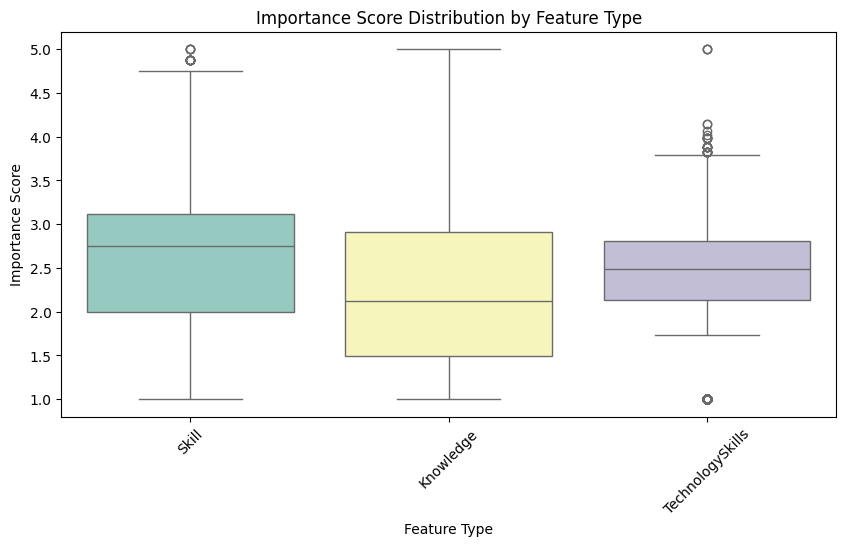

In [10]:
plt.figure(figsize=(10,5))
sns.boxplot(data=unified_occupation_dataset, 
            x='Feature_Type', 
            y='Importance_Score', 
            palette='Set3',
            hue = 'Feature_Type')
plt.title("Importance Score Distribution by Feature Type")
plt.xlabel("Feature Type")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)
plt.show()

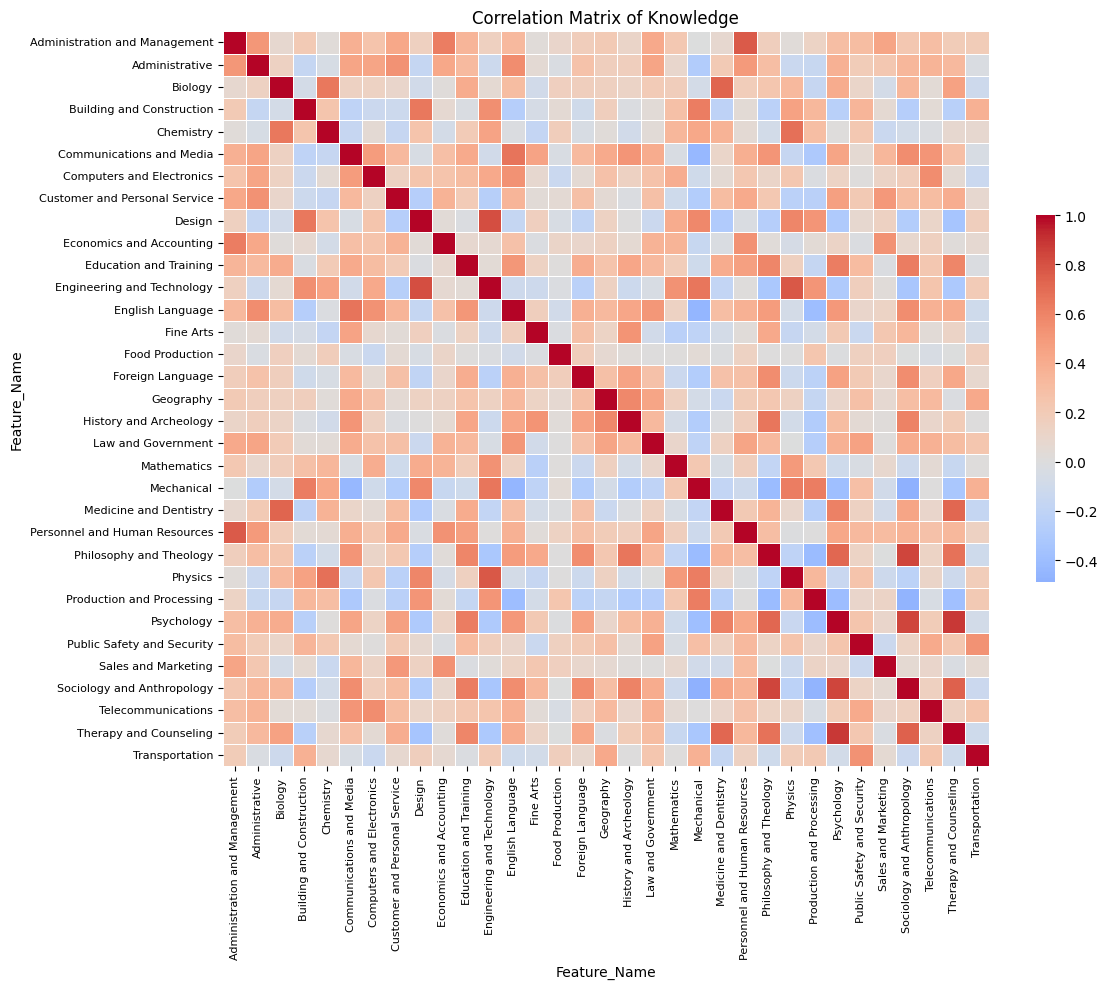

In [ ]:
df_skill = unified_occupation_dataset[unified_occupation_dataset['Feature_Type'] == 'Knowledge']
skill_pivot = df_skill.pivot(index='Title', columns='Feature_Name', values='Importance_Score')
# Fill NA with 1.0 (min score)
skill_pivot = skill_pivot.fillna(1.0)

plt.figure(figsize=(12, 10))
# Calculate correlation
corr = skill_pivot.corr()
# Plot heatmap
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=.5, cbar_kws={"shrink": .5}, xticklabels=True, yticklabels=True)
plt.title('Correlation Matrix of Knowledge')
plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()

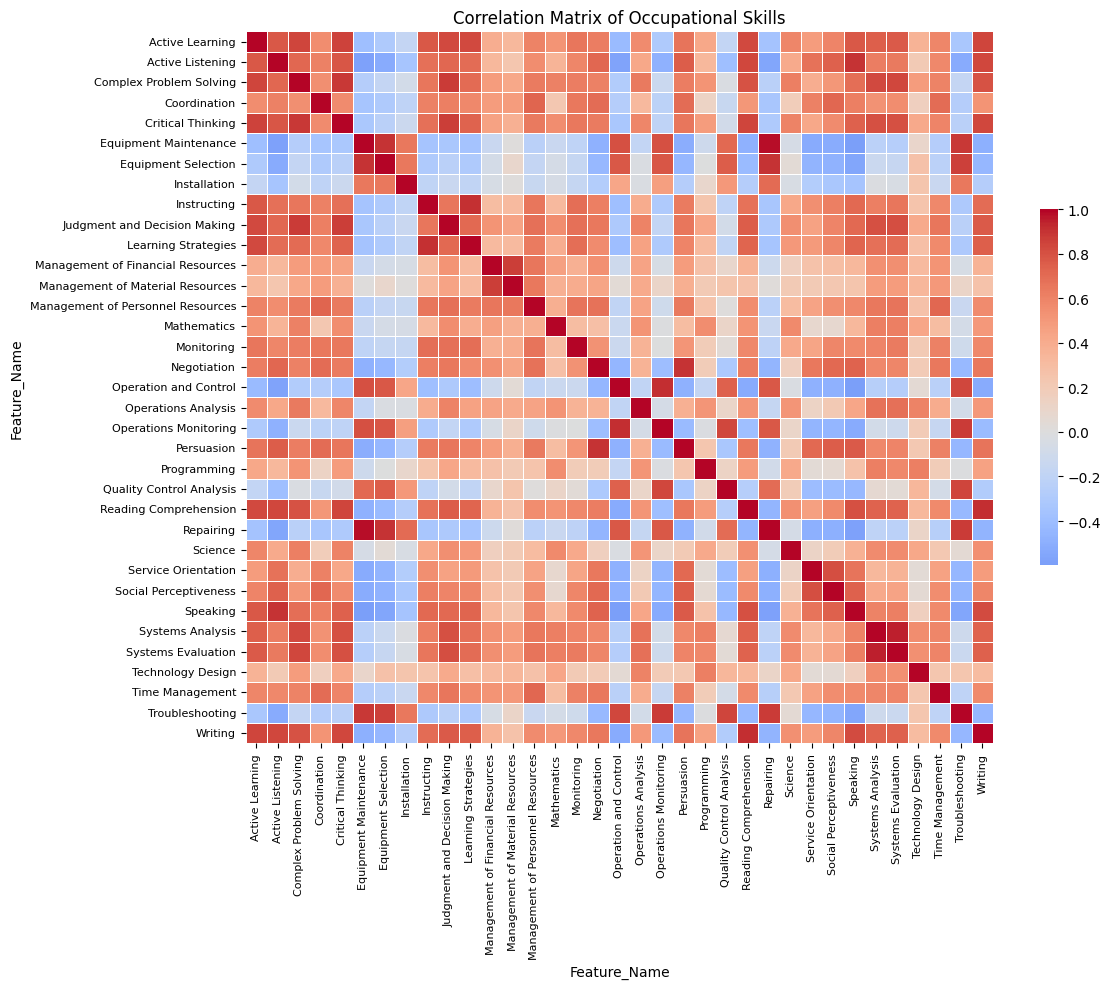

In [12]:
# Filter for 'Skill' type
df_skill = unified_occupation_dataset[unified_occupation_dataset['Feature_Type'] == 'Skill']
# Pivot: Rows=Title, Cols=Feature_Name, Values=Importance_Score
skill_pivot = df_skill.pivot(index='Title', columns='Feature_Name', values='Importance_Score')
# Fill NA with 1.0 (min score)
skill_pivot = skill_pivot.fillna(1.0)

plt.figure(figsize=(12, 10))
# Calculate correlation
corr = skill_pivot.corr()
# Plot heatmap
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=.5, cbar_kws={"shrink": .5}, xticklabels=True, yticklabels=True)
plt.title('Correlation Matrix of Occupational Skills')
plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()

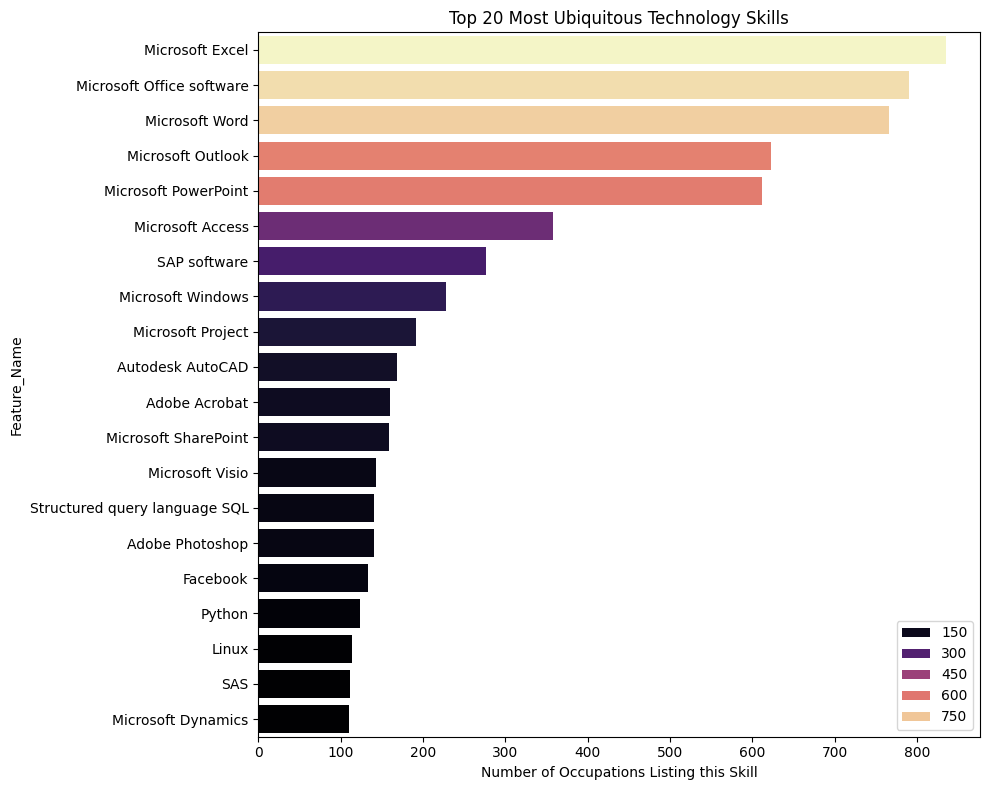

In [14]:
df_tech = unified_occupation_dataset[unified_occupation_dataset['Feature_Type'] == 'TechnologySkills']
tech_counts = df_tech['Feature_Name'].value_counts().head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x=tech_counts.values, 
            y=tech_counts.index, 
            palette='magma',
            hue=tech_counts.values)
plt.title('Top 20 Most Ubiquitous Technology Skills')
plt.xlabel('Number of Occupations Listing this Skill')
plt.tight_layout()